In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest


In [55]:
df = pd.read_csv("marketing_AB.csv")
df.rename(columns={df.columns[0]: 'sr_no'}, inplace=True)

In [56]:
# First % rows
df.head()

,sr_no,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [57]:
# Last 5 rows
df.tail()

,sr_no,user id,test group,converted,total ads,most ads day,most ads hour
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23
588100,588100,1237779,ad,False,1,Tuesday,23


In [58]:
print("Shape of the Data: ")
print(df.shape)

Shape of the Data: 
(588101, 7)


In [59]:
df.columns = (
    df.columns
        .str.strip()
        .str.replace(' ', '_')
)
df.columns

Index(['sr_no', 'user_id', 'test_group', 'converted', 'total_ads',
       'most_ads_day', 'most_ads_hour'],
      dtype='object')

In [60]:
print("Summary of the dataset: ")
print(df.info())

Summary of the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   sr_no          588101 non-null  int64 
 1   user_id        588101 non-null  int64 
 2   test_group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total_ads      588101 non-null  int64 
 5   most_ads_day   588101 non-null  object
 6   most_ads_hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 23.0+ MB
None


In [61]:
# Datatypes of Each Column
print("Datatypes of Each Column :")
print(df.dtypes)

Datatypes of Each Column :
sr_no             int64
user_id           int64
test_group       object
converted          bool
total_ads         int64
most_ads_day     object
most_ads_hour     int64
dtype: object


In [62]:
# Numerical Columns Statistical Summary
print("Statistic Summary for Numerical Columns:")
print(df.describe())

Statistic Summary for Numerical Columns:
               sr_no       user_id      total_ads  most_ads_hour
count  588101.000000  5.881010e+05  588101.000000  588101.000000
mean   294050.000000  1.310692e+06      24.820876      14.469061
std    169770.279668  2.022260e+05      43.715181       4.834634
min         0.000000  9.000000e+05       1.000000       0.000000
25%    147025.000000  1.143190e+06       4.000000      11.000000
50%    294050.000000  1.313725e+06      13.000000      14.000000
75%    441075.000000  1.484088e+06      27.000000      18.000000
max    588100.000000  1.654483e+06    2065.000000      23.000000


In [63]:
# Missing Values check
missing_values = df.isnull().sum()
print("Missing Values for Each Column")
print(missing_values)

Missing Values for Each Column
sr_no            0
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64


In [64]:
# Duplicate values Check
duplicates = df.duplicated().sum()
print("Duplicate Row Count: ")
print(duplicates)

Duplicate Row Count: 
0


In [65]:
# count for test group categories
df['test_group'].value_counts()

test_group
ad     564577
psa     23524
Name: count, dtype: int64

In [66]:
# # count for converted categories
df['converted'].value_counts()

converted
False    573258
True      14843
Name: count, dtype: int64

In [67]:
# Convert True/False to 1/0
df['converted'] = df['converted'].astype(int)
df.head()

,sr_no,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,0,1069124,ad,0,130,Monday,20
1,1,1119715,ad,0,93,Tuesday,22
2,2,1144181,ad,0,21,Tuesday,18
3,3,1435133,ad,0,355,Tuesday,10
4,4,1015700,ad,0,276,Friday,14


In [68]:
# conversion rate for A/B testing using mean
conversion_rate = df.groupby('test_group')['converted'].mean()
print(conversion_rate)

test_group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64


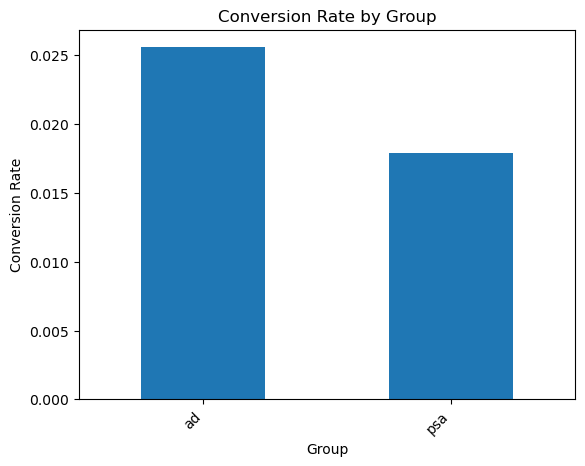

In [69]:
# Conversion Rate
conversion_rate.plot(kind='bar')
plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.xticks(rotation = 45 , ha = "right")
plt.show()

In [70]:
# Aggregate Data
summary = df.groupby('test_group')['converted'].agg(['sum','count'])
summary.columns = ['conversions','users']

print(summary)

            conversions   users
test_group                     
ad                14423  564577
psa                 420   23524


In [73]:
#Sample Ratio Mismatch
observed = summary['users']
expected = [sum(observed)/2, sum(observed)/2]

chi_stat, p_val_srm = chisquare(observed, expected)

print("SRM p-value:", p_val_srm)
print("\nObserved group sizes:", observed)
print("SRM check not applied because expected traffic split is unknown.")

SRM p-value: 0.0

Observed group sizes: test_group
ad     564577
psa     23524
Name: users, dtype: int64
SRM check not applied because expected traffic split is unknown.


In [74]:
# Z-Test
conversions = summary['conversions']
users = summary['users']

z_stat, p_value = proportions_ztest(conversions, users)

print("P-value:", p_value)

P-value: 1.7052807161559727e-13


In [75]:
# Lift Calculation
alpha = 0.05
rate_A = conversion_rate['ad']
rate_B = conversion_rate['psa']
lift = (rate_A - rate_B) / rate_B

print("Lift:", lift)

Lift: 0.43085064022225833


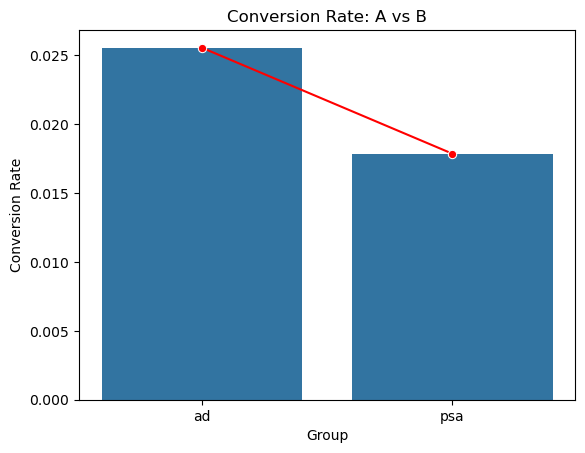

In [76]:
plot_df = conversion_rate.reset_index()
plot_df.columns = ['Group', 'Conversion Rate']

# Bar plot
sns.barplot(data=plot_df, x='Group', y='Conversion Rate')

# Line plot 
sns.lineplot(data=plot_df, x='Group', y='Conversion Rate', marker='o' , color='red')
plt.title("Conversion Rate: A vs B")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.show()

In [77]:
# Confidence Interval
n_A = summary.loc['ad','users']
n_B = summary.loc['psa','users']

diff = rate_A - rate_B

se = np.sqrt((rate_A*(1-rate_A)/n_A) + (rate_B*(1-rate_B)/n_B))

ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se

print("95% CI:", (ci_lower, ci_upper))

95% CI: (np.float64(0.00595090043017032), np.float64(0.009434005954232714))


In [78]:
#  Chi-Square Test
contingency = pd.crosstab(df['test_group'], df['converted'])
chi2, p_chi, dof, expected = chi2_contingency(contingency)

print("\nChi-square P-value:", p_chi)


Chi-square P-value: 1.9989623063390075e-13



Chi-square: chi2=54.01, p=1.9990e-13, dof=1
Contingency Table:
converted        0      1
test_group               
ad          550154  14423
psa          23104    420
Expected counts:
converted              0            1
test_group                           
ad          550327.71899  14249.28101
psa          22930.28101    593.71899


Text(0.5, 1.0, 'Standardized Residuals')

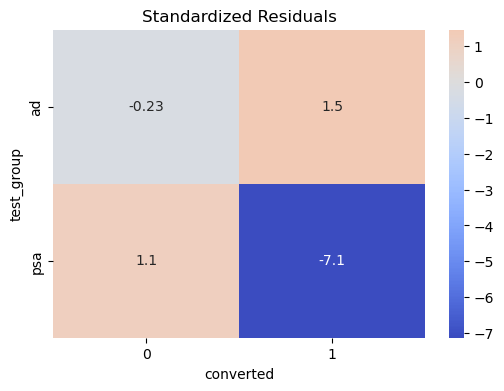

In [79]:
# Chi-square
ct = pd.crosstab(df['test_group'], df['converted'])
chi2, p_chi2, dof, expected = chi2_contingency(ct)

print(f"\nChi-square: chi2={chi2:.2f}, p={p_chi2:.4e}, dof={dof}")
print(f"Contingency Table:\n{ct}")
print(f"Expected counts:\n{pd.DataFrame(expected, index=ct.index, columns=ct.columns)}")

# Visualisation
residuals = (ct - expected) / np.sqrt(expected)
plt.figure(figsize=(6,4))
sns.heatmap(residuals, annot=True, cmap='coolwarm', center=0)
plt.title('Standardized Residuals')

In [80]:
#  Final Conclusion
if p_value < alpha:
    if rate_B > rate_A:
        print(" Launch Campaign PSA")
    else:
        print("Keep Campaign Ad")
else:
    print(" No significant difference")

Keep Campaign Ad
